In [2]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectFdr, chi2, f_classif, f_regression
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
data = pd.read_csv("./sleep_health_dataset.csv")
data.head()

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


Make some obvious steps to describe data in dataset

In [4]:
data.describe()

,person_id,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,...,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,cognitive_performance_score,felt_rested
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,34.706870,26.289673,6.423986,4.871144,20.243968,20.253375,19.836810,3.346610,38.849500,...,14.936840,5.733285,7.134059,66.57017,0.561610,0.084420,20.538093,1.200634,59.227295,0.390120
std,28867.657797,11.036373,4.479578,1.274627,1.506517,3.411354,4.251096,7.584343,1.920877,69.395818,...,21.387567,1.619194,3.482878,7.22821,0.496192,0.278018,2.897565,0.786667,22.249665,0.487779
min,1.000000,18.000000,16.000000,3.000000,1.000000,10.000000,5.000000,1.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,45.00000,0.000000,0.000000,15.000000,-1.000000,0.000000,0.000000
25%,25000.750000,26.000000,23.200000,5.530000,3.800000,18.000000,17.400000,14.000000,2.000000,0.000000,...,0.000000,4.800000,4.700000,62.00000,0.000000,0.000000,18.500000,0.670000,44.200000,0.000000
50%,50000.500000,33.000000,26.300000,6.360000,4.900000,20.300000,20.300000,19.000000,3.000000,0.000000,...,0.000000,5.800000,7.400000,67.00000,1.000000,0.000000,20.500000,1.200000,60.400000,0.000000
75%,75000.250000,42.000000,29.300000,7.270000,6.000000,22.600000,23.200000,25.000000,5.000000,80.000000,...,30.000000,6.800000,9.700000,71.00000,1.000000,0.000000,22.500000,1.740000,75.800000,1.000000
max,100000.000000,69.000000,45.000000,10.500000,10.000000,30.000000,30.000000,58.000000,8.000000,400.000000,...,116.000000,10.000000,18.000000,99.00000,1.000000,1.000000,28.000000,3.000000,100.000000,1.000000


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  object 
 3   occupation                   100000 non-null  object 
 4   bmi                          100000 non-null  float64
 5   country                      100000 non-null  object 
 6   sleep_duration_hrs           100000 non-null  float64
 7   sleep_quality_score          100000 non-null  float64
 8   rem_percentage               100000 non-null  float64
 9   deep_sleep_percentage        100000 non-null  float64
 10  sleep_latency_mins           100000 non-null  int64  
 11  wake_episodes_per_night      100000 non-null  int64  
 12  caffeine_mg_before_bed       100000 non-null  int64  
 13  

In [6]:
data = data.drop(columns=["person_id"])

Extract numeric, categoric and binary features into different lists

In [7]:
numeric_features = data.select_dtypes(include="number").columns.tolist()

binary_features = [c for c in numeric_features if data[c].nunique() == 2]
cont_features = [c for c in numeric_features if c not in binary_features]

binary_features

['exercise_day', 'sleep_aid_used', 'shift_work', 'felt_rested']

From first look we can't find any anomaly but let's take a deeper look. Find outliers if it exists

In [8]:
outliers_report = []

for col in cont_features:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    what_find = ((data[col] > upper_bound) | (data[col] < lower_bound)).sum()
    if what_find > 0:
        data[col] = data[col].clip(lower=lower_bound, upper=upper_bound)
        outliers_report.append({"Column": col, "Count": what_find})


pd.DataFrame(outliers_report)
# if outliers_report:
#     print("------ We find some outliers. Let's take a look")
# else:
#     print("------ Where were not any outliers!") 
    

,Column,Count
0,age,341
1,bmi,341
2,sleep_duration_hrs,545
3,sleep_quality_score,12
4,rem_percentage,778
5,deep_sleep_percentage,402
6,sleep_latency_mins,368
7,caffeine_mg_before_bed,2408
8,alcohol_units_before_bed,7572
9,screen_time_before_bed_mins,5781


Now let take a look at categorical features

In [9]:
cat_features = data.select_dtypes(include="object").columns.tolist()

for col in cat_features:
    print(f"Column is {col} have values such as \t =>> \t {data[col].unique().tolist()}")

Column is gender have values such as 	 =>> 	 ['Female', 'Male', 'Other']
Column is occupation have values such as 	 =>> 	 ['Driver', 'Software Engineer', 'Nurse', 'Student', 'Lawyer', 'Freelancer', 'Manager', 'Doctor', 'Homemaker', 'Teacher', 'Retired', 'Sales']
Column is country have values such as 	 =>> 	 ['Japan', 'USA', 'India', 'Spain', 'Brazil', 'Netherlands', 'UK', 'Germany', 'South Korea', 'Australia', 'Canada', 'Italy', 'France', 'Sweden', 'Mexico']
Column is chronotype have values such as 	 =>> 	 ['Morning', 'Neutral', 'Evening']
Column is mental_health_condition have values such as 	 =>> 	 ['Healthy', 'Both', 'Depression', 'Anxiety']
Column is season have values such as 	 =>> 	 ['Autumn', 'Winter', 'Spring', 'Summer']
Column is day_type have values such as 	 =>> 	 ['Weekday', 'Weekend']
Column is sleep_disorder_risk have values such as 	 =>> 	 ['Healthy', 'Severe', 'Mild', 'Moderate']


In [10]:
pd.DataFrame({"Jobs": data["occupation"].unique().tolist()})

,Jobs
0,Driver
1,Software Engineer
2,Nurse
3,Student
4,Lawyer
5,Freelancer
6,Manager
7,Doctor
8,Homemaker
9,Teacher


Было бы интересно проверить, насколько схож cognitive_performance_score у людей разных профессий

In [11]:
df = data.copy()

/tmp/ipykernel_87858/1133308318.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sub, x='occupation', y='cognitive_performance_score',
/tmp/ipykernel_87858/1133308318.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_sub, x='occupation', y='cognitive_performance_score',


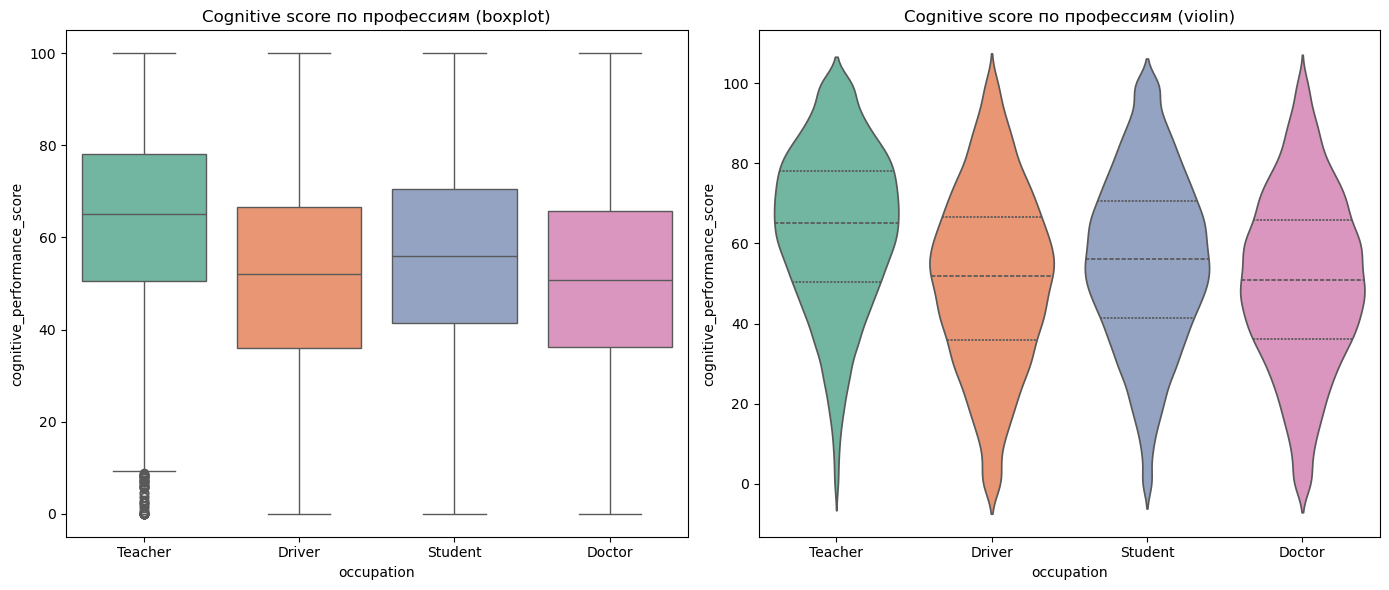

,mean,median,std,count
occupation,,,,
Doctor,50.558,50.8,21.432,7868
Driver,51.149,52.0,21.954,6996
Student,55.652,56.0,21.103,14851
Teacher,63.449,65.1,19.997,8047


In [12]:
# Фильтруем нужные группы
groups_of_interest = ['Teacher', 'Driver', 'Student', 'Doctor']
df_sub = df[df['occupation'].isin(groups_of_interest)].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot — сразу видны медианы, IQR, выбросы
sns.boxplot(data=df_sub, x='occupation', y='cognitive_performance_score',
            order=groups_of_interest, palette='Set2', ax=axes[0])
axes[0].set_title('Cognitive score по профессиям (boxplot)')

# Violin — показывает форму распределения, не только квантили
sns.violinplot(data=df_sub, x='occupation', y='cognitive_performance_score',
               order=groups_of_interest, palette='Set2', inner='quartile', ax=axes[1])
axes[1].set_title('Cognitive score по профессиям (violin)')

plt.tight_layout()
plt.show()

# Описательная статистика
df_sub.groupby('occupation')['cognitive_performance_score'].agg(
    ['mean', 'median', 'std', 'count']
).round(3)

Интересно получается, что у докоторов когнитивные способности далеко не самые лучшие из выбранной группы.
Давай те проверим распределения у данных подгрупп на нормальность, а заодно проверим не скрывается ли в каждой подгруппе дополнительной неоднороднотсти(гетерогенности)   

In [13]:
def multi_sample_qqplot(series, n_samples=3, sample_size=3000, group_name='', random_state=42):
    fig, axes = plt.subplots(1, n_samples, figsize=(5 * n_samples, 4))
    
    for i, ax in enumerate(axes):
        sample = series.sample(sample_size, random_state=random_state + i * 3)
        (osm, osr), (slope, intercept, r) = stats.probplot(sample, dist='norm')
        
        ax.plot(osm, osr, 'o', alpha=0.3, markersize=2, color='steelblue')
        ax.plot(osm, slope * np.array(osm) + intercept, 
                'r-', linewidth=1.5, label=f'R²={r**2:.4f}')
        ax.set_title(f'{group_name} — выборка {i+1}\nn={sample_size}')
        ax.legend(fontsize=9)
        ax.set_xlabel('Теоретические квантили')
        ax.set_ylabel('Наблюдаемые квантили')
    
    plt.suptitle(f'Стабильность Q-Q plot: {group_name}', y=1.02)
    plt.tight_layout()
    plt.show()

In [14]:
def stability_check(series, n_iter=20, sample_size=2000):
    p_values = [
        stats.shapiro(series.sample(sample_size, random_state=i))[1]
        for i in range(n_iter)
    ]
    p_arr = np.array(p_values)
    print(f"p-value: min={p_arr.min():.4f}, max={p_arr.max():.4f}, "
          f"mean={p_arr.mean():.4f}, std={p_arr.std():.4f}")
    print(f"Доля итераций с p>0.05: {(p_arr > 0.05).mean():.0%}")

In [15]:
def stable_qqplot(series, n_samples=4, sample_size=2000,
                  group_name='', random_state=42):
    """
    Накладывает несколько Q-Q plots друг на друга на одних осях.
    Если линии совпадают — форма стабильна и одной выборки хватало бы.
    Если расходятся — группа гетерогенна(неоднородна).
    """
    _, (ax_overlay, ax_diff) = plt.subplots(1, 2, figsize=(12, 5))
    
    all_residuals = []
    colors = plt.cm.tab10(np.linspace(0, 0.4, n_samples))

    for i in range(n_samples):
        sample = series.sample(sample_size, random_state=random_state + i)
        (osm, osr), (slope, intercept, r) = stats.probplot(sample, dist='norm')
        
        residuals = np.array(osr) - (slope * np.array(osm) + intercept)
        all_residuals.append(residuals)
        
        # Левый график — наложенные Q-Q plots
        ax_overlay.plot(osm, osr, 'o', alpha=0.15, markersize=2, color=colors[i])
        ax_overlay.plot(osm, slope * np.array(osm) + intercept,
                       linewidth=1.5, color=colors[i], label=f'выборка {i+1}  R²={r**2:.4f}')

    ax_overlay.set_title(f'{group_name} — наложенные Q-Q plots\n'
                         f'(совпадение линий = стабильное распределение)')
    ax_overlay.set_xlabel('Теоретические квантили')
    ax_overlay.set_ylabel('Наблюдаемые квантили')
    ax_overlay.legend(fontsize=8)

    # Правый график — отклонения от теоретической линии
    # Если группа однородна — все кривые идут близко к нулю
    residuals_arr = np.array(all_residuals)
    x_axis = np.linspace(0, 1, residuals_arr.shape[1])
    
    for i, res in enumerate(residuals_arr):
        ax_diff.plot(x_axis, res, alpha=0.6, linewidth=1.2,
                    color=colors[i], label=f'выборка {i+1}')
    
    # Коридор ± std по всем выборкам — визуальная мера разброса
    mean_res = residuals_arr.mean(axis=0)
    std_res = residuals_arr.std(axis=0)
    ax_diff.fill_between(x_axis, mean_res - std_res, mean_res + std_res,
                         alpha=0.15, color='gray', label='±1 std коридор')
    ax_diff.axhline(0, color='red', linewidth=1, linestyle='--')
    ax_diff.set_title('Отклонения от теоретической нормальной линии\n'
                      '(узкий коридор = стабильная форма)')
    ax_diff.set_xlabel('Квантиль (0=min, 1=max)')
    ax_diff.set_ylabel('Отклонение')
    ax_diff.legend(fontsize=8)

    plt.suptitle(f'Стабильность распределения: {group_name}', 
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Единственное число которое считаем — разброс между выборками,
    # не p-value, а просто описательная статистика стабильности
    max_spread = np.abs(residuals_arr.max(axis=0) - 
                        residuals_arr.min(axis=0)).mean()
    print(f"{group_name}: средний разброс между выборками = {max_spread:.4f}")
    print("  → близко к 0: форма стабильна, одной выборки достаточно")
    print("  → большой разброс: группа гетерогенна, стоит исследовать подгруппы\n")

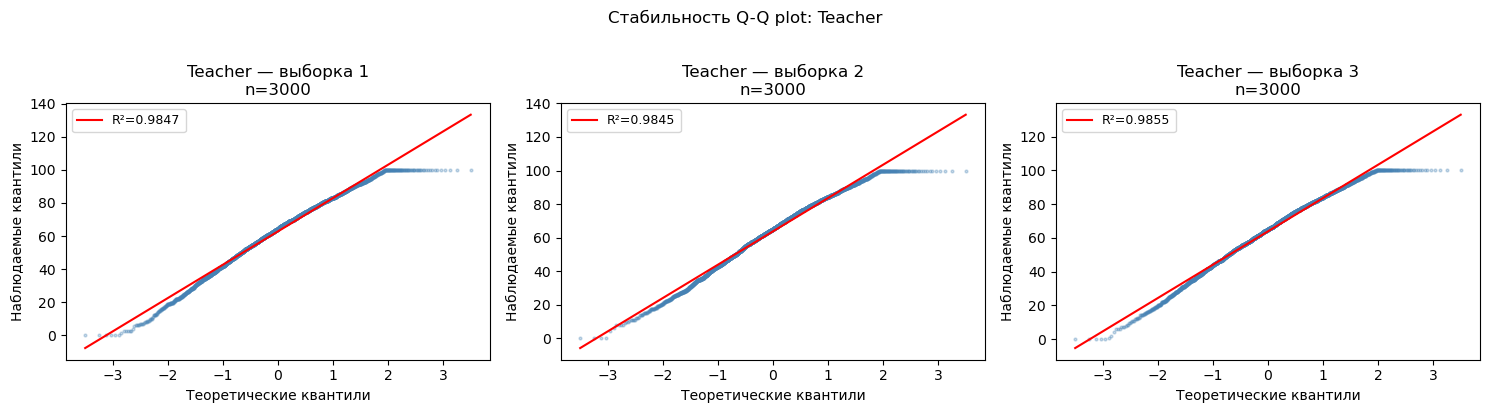

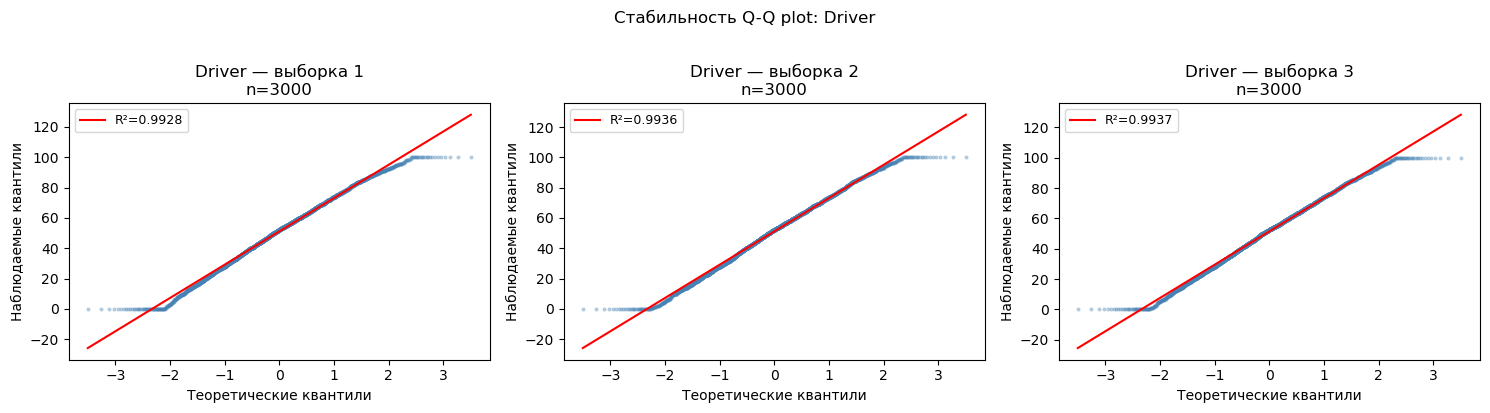

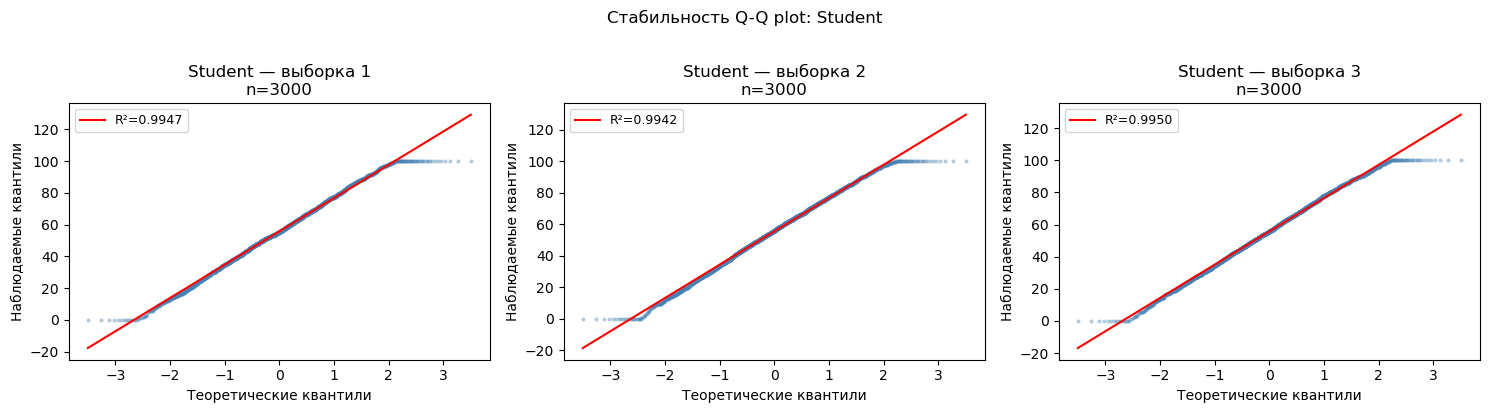

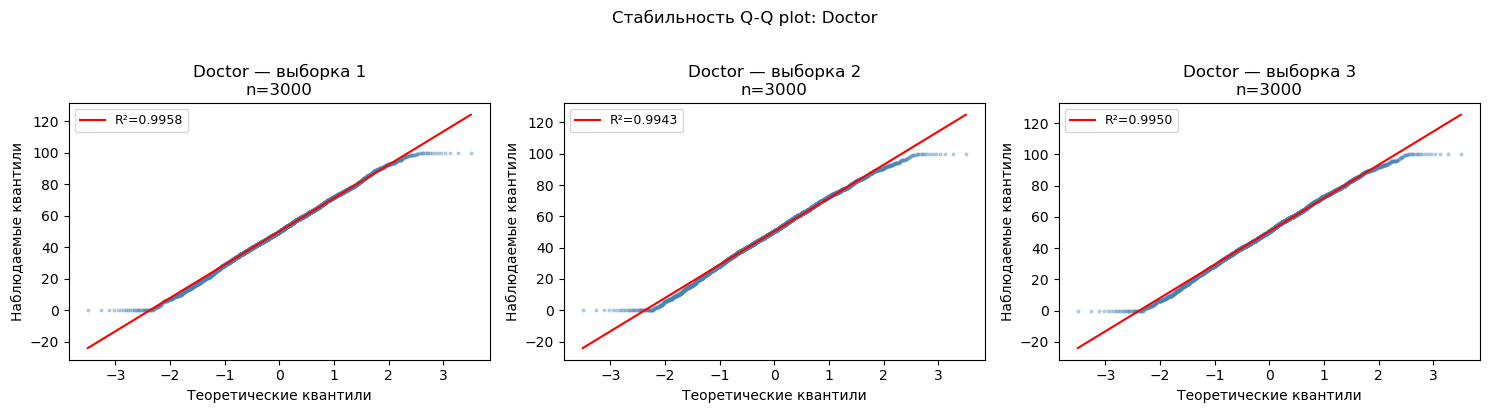

In [16]:
for occ in groups_of_interest:
    group = df[df["occupation"] == occ]["cognitive_performance_score"].dropna()
    multi_sample_qqplot(group, group_name=occ)

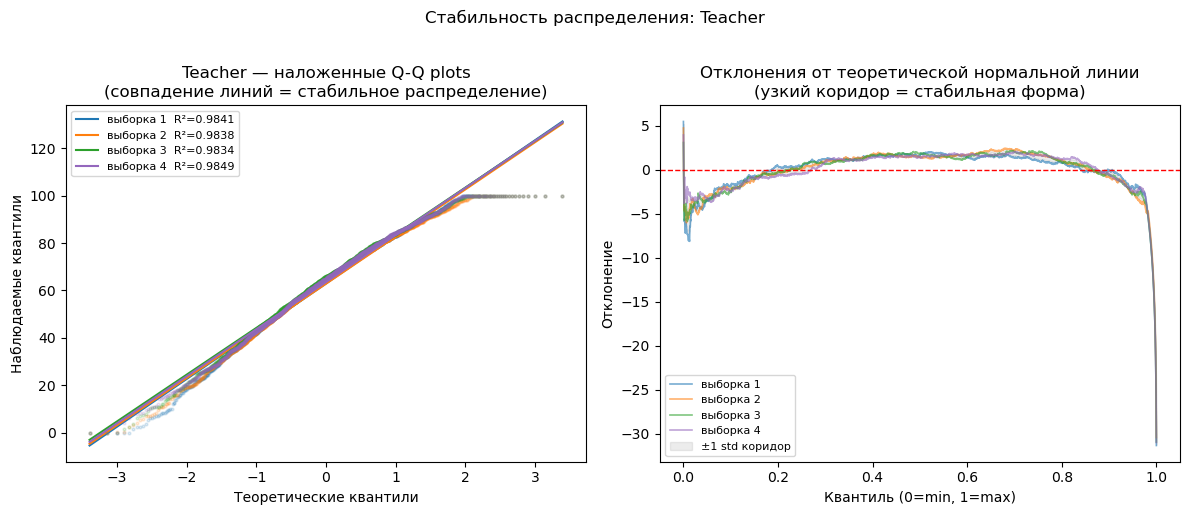

Teacher: средний разброс между выборками = 0.7139
  → близко к 0: форма стабильна, одной выборки достаточно
  → большой разброс: группа гетерогенна, стоит исследовать подгруппы



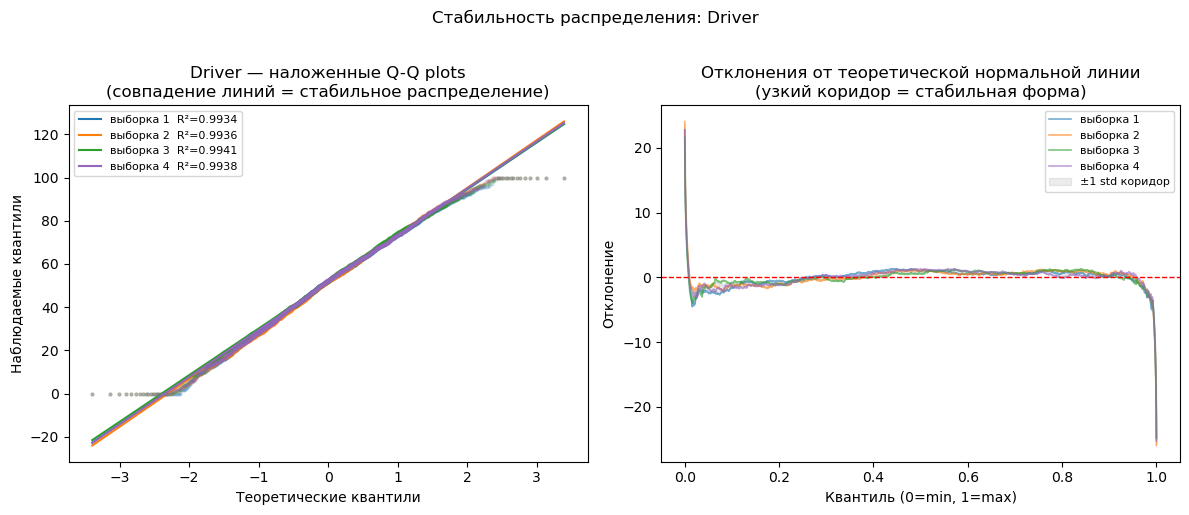

Driver: средний разброс между выборками = 0.7273
  → близко к 0: форма стабильна, одной выборки достаточно
  → большой разброс: группа гетерогенна, стоит исследовать подгруппы



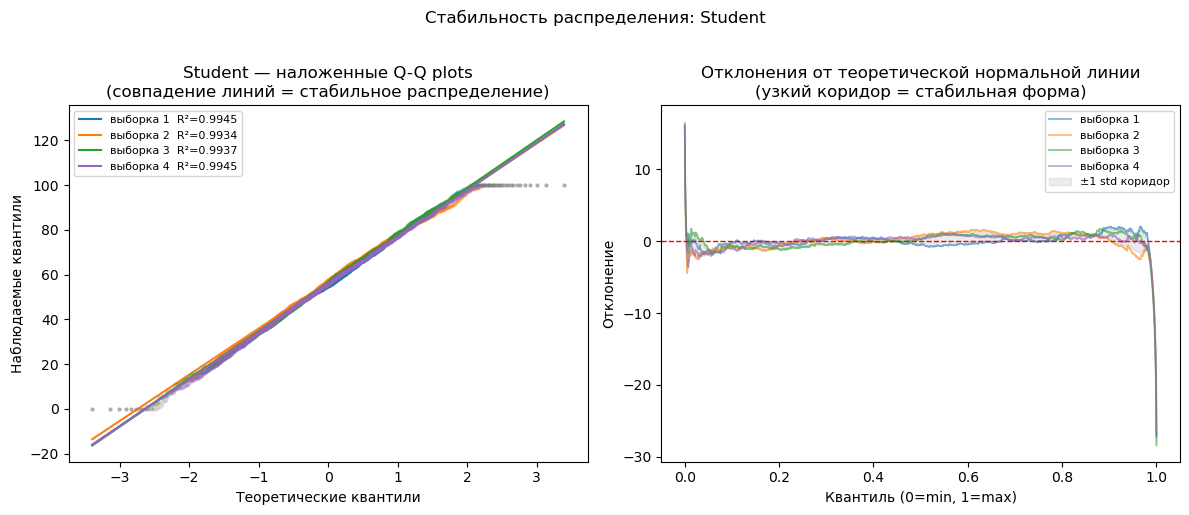

Student: средний разброс между выборками = 1.2254
  → близко к 0: форма стабильна, одной выборки достаточно
  → большой разброс: группа гетерогенна, стоит исследовать подгруппы



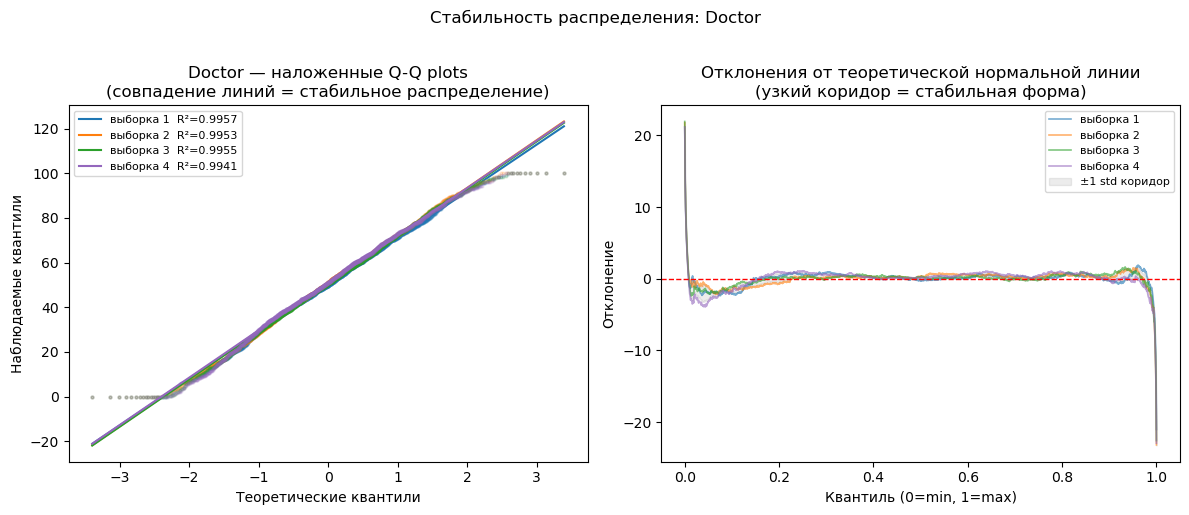

Doctor: средний разброс между выборками = 0.8360
  → близко к 0: форма стабильна, одной выборки достаточно
  → большой разброс: группа гетерогенна, стоит исследовать подгруппы



In [17]:
for occ in groups_of_interest:
    stable_qqplot(df[df["occupation"] == occ]["cognitive_performance_score"].dropna(), group_name=occ)

Из такого наглядного примера видно, что доктора распределены однородно и в них нет подгруппы каких-то особых докоторов у которых все замечательнее остальных

Наверно возник вопрос, а почему мы не можем просто кучу раз запустить тест Shapiro, собрать результирующие p-value в список и просто посмотреть а сколько у нас таких p-value будет меньше 0.05 а сколько больше и на этом сделать вывод. Если коротко, то это подгонка под наше желание найти неоднородности в данных, а если умным словом то это p-hacking и заниматься таким зазорно. Лучше проиллюстрировать на графики несколько сэмплов и на глаз понять, все ли на устраивает.

Так же можно обратить внимание на то, что у нас хвосты якобы имеют изгибы, но это не так, потому что у нас максимальное и минимальное значения соответственно равны 100 и 0, такое видно из первичного описания датасета и при взгляде на __наблюдаемые квантили__

#### Методом пристального взгляда установили близость к нормальному распределению этих выборок, теперь построим пайплайн для дальнейшего анализа наших категорий 


In [18]:
def normality_effect_size(series, group_name=''):
    """
    W-статистика Шапиро сама по себе — это и есть effect size:
    W=1.0 означает идеальную нормальность,
    W=0.95+ на практике считается 'достаточно нормальным'.
    p-value игнорируем — смотрим только на W.
    """
    W, p = stats.shapiro(series)
    
    print(f"\n{group_name}:")
    print(f"  W = {W:.6f}  ←  смотрим сюда, не на p-value")
    print(f"  p = {p:.2e}  ←  бессмысленно при n=2000, игнорируем")
    
    if W > 0.99:
        verdict = "практически идеальная нормальность"
    elif W > 0.97:
        verdict = "очень близко к нормальному, параметрика применима"
    elif W > 0.95:
        verdict = "незначительное отклонение, параметрика обычно применима"
    elif W > 0.90:
        verdict = "умеренное отклонение, лучше Welch + проверить выбросы"
    else:
        verdict = "существенное отклонение, предпочесть непараметрику"
    
    print(f"=> {verdict}")
    return W

In [19]:
def levene_effect_size(groups_dict):
    """
    Смотрим на ratio дисперсий, а не на p-value Левена.
    """
    stds = {name: arr.std() for name, arr in groups_dict.items()}
    vars_ = {name: arr.var() for name, arr in groups_dict.items()}
    
    max_var = max(vars_.values())
    min_var = min(vars_.values())
    ratio = max_var / min_var
    
    print(f"\nСтандартные отклонения:")
    for name, std in stds.items():
        print(f"  {name}: std = {std:.4f}")
    
    print(f"\nRatio дисперсий (max/min): {ratio:.4f}")
    
    if ratio < 1.5:
        verdict = "дисперсии практически равны → Student t-test"
        use_welch = False
    elif ratio < 4.0:
        verdict = "умеренное различие → Welch t-test (на всякий случай)"
        use_welch = True
    else:
        verdict = "существенное различие → однозначно Welch t-test"
        use_welch = True
    
    print(f"=> {verdict}")
    return use_welch

In [20]:
normality_effect_size(df[df["occupation"] == "Doctor"]["cognitive_performance_score"], group_name="Doctor")


Doctor:
  W = 0.994461  ←  смотрим сюда, не на p-value
  p = 6.84e-17  ←  бессмысленно при n=2000, игнорируем
=> практически идеальная нормальность


/home/mello/anaconda3/envs/ml_project_env/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7868.
  res = hypotest_fun_out(*samples, **kwds)


np.float64(0.9944609829724427)

In [21]:
def compare_groups(df, col, group_col, g1_name, g2_name, 
                   alpha=0.05, sample_size=2000, random_state=42):

    g1_full = df[df[group_col] == g1_name][col].dropna()
    g2_full = df[df[group_col] == g2_name][col].dropna()
    
    # Сэмплы — используем везде одинаково
    g1 = g1_full.sample(min(sample_size, len(g1_full)), random_state=random_state)
    g2 = g2_full.sample(min(sample_size, len(g2_full)), random_state=random_state)
    
    print(f"\n{'='*55}")
    print(f"Сравнение: {g1_name} (n={len(g1_full)}, "
          f"в тесте n={len(g1)}) vs "
          f"{g2_name} (n={len(g2_full)}, в тесте n={len(g2)})")
    print(f"{'='*55}")
    print(f"  {g1_name}: mean={g1_full.mean():.3f}, "  # описательное — на полных
          f"sd={g1_full.std():.3f}, median={g1_full.median():.3f}")
    print(f"  {g2_name}: mean={g2_full.mean():.3f}, "
          f"sd={g2_full.std():.3f}, median={g2_full.median():.3f}")
    
    # Нормальность, Левен и сам тест — все на одних и тех же сэмплах
    w1 = normality_effect_size(g1, group_name=g1_name)
    w2 = normality_effect_size(g2, group_name=g2_name)
    both_normal = (w1 > 0.95) and (w2 > 0.95)
    
    if both_normal:
        use_welch = levene_effect_size({g1_name: g1, g2_name: g2})
        stat, p_val = stats.ttest_ind(g1, g2, equal_var=(not use_welch))
        test_name = "Welch t-test" if use_welch else "Student t-test"
        
        pooled_std = np.sqrt(
            ((len(g1)-1)*g1.std()**2 + (len(g2)-1)*g2.std()**2)
            / (len(g1) + len(g2) - 2)
        )
        effect_size = abs(g1.mean() - g2.mean()) / pooled_std
        effect_label = ("маленький" if effect_size < 0.2 else
                        "средний"   if effect_size < 0.8 else "большой")
    else:
        stat, p_val = stats.mannwhitneyu(g1, g2, alternative='two-sided')
        test_name = "Mann-Whitney U"
        n1, n2 = len(g1), len(g2)
        effect_size = abs(1 - (2 * stat) / (n1 * n2))
        effect_label = ("маленький" if effect_size < 0.1 else
                        "средний"   if effect_size < 0.3 else "большой")
    
    print(f"\n  Тест: {test_name} (на сэмпле n={len(g1)})")
    print(f"  stat={stat:.3f}, p={p_val:.4f}")
    print(f"  Результат: {'ЗНАЧИМО!' if p_val < alpha else 'НЕ значимо!'}")
    print(f"  Размер эффекта: {effect_size:.3f} — {effect_label}")
    
    return {
        'test': test_name,
        'stat': round(stat, 4),
        'p_value': round(p_val, 4),
        'significant': p_val < alpha,
        'effect_size': round(effect_size, 4),
        'effect_label': effect_label
    }

# Запускаем сравнения
r1 = compare_groups(df, 'cognitive_performance_score', 'occupation',
                    'Teacher', 'Driver')
r2 = compare_groups(df, 'cognitive_performance_score', 'occupation',
                    'Student', 'Doctor')

print(r1, r2, sep="\n")


Сравнение: Teacher (n=8047, в тесте n=2000) vs Driver (n=6996, в тесте n=2000)
  Teacher: mean=63.449, sd=19.997, median=65.100
  Driver: mean=51.149, sd=21.954, median=52.000

Teacher:
  W = 0.983536  ←  смотрим сюда, не на p-value
  p = 2.02e-14  ←  бессмысленно при n=2000, игнорируем
=> очень близко к нормальному, параметрика применима

Driver:
  W = 0.992684  ←  смотрим сюда, не на p-value
  p = 1.94e-08  ←  бессмысленно при n=2000, игнорируем
=> практически идеальная нормальность

Стандартные отклонения:
  Teacher: std = 20.2989
  Driver: std = 21.7946

Ratio дисперсий (max/min): 1.1528
=> дисперсии практически равны → Student t-test

  Тест: Student t-test (на сэмпле n=2000)
  stat=17.892, p=0.0000
  Результат: ЗНАЧИМО!
  Размер эффекта: 0.566 — средний

Сравнение: Student (n=14851, в тесте n=2000) vs Doctor (n=7868, в тесте n=2000)
  Student: mean=55.652, sd=21.103, median=56.000
  Doctor: mean=50.558, sd=21.432, median=50.800

Student:
  W = 0.993820  ←  смотрим сюда, не на p-

##### Проверим устойчивость Cohen's d

In [22]:
def sensitivity_analysis(g1_full, g2_full, sample_sizes=None):
    """
    Показывает как p-value и effect size ведут себя
    при разных размерах выборки.
    Если effect size стабилен — эффект реальный.
    Если скачет — артефакт выборки.
    """
    if sample_sizes is None:
        sample_sizes = [50, 100, 200, 500, 1000, 2000]
    
    rows = []
    for n in sample_sizes:
        if n > min(len(g1_full), len(g2_full)):
            continue
            
        s1 = g1_full.sample(n, random_state=42)
        s2 = g2_full.sample(n, random_state=42)
        
        _, p = stats.ttest_ind(s1, s2)
        
        pooled_std = np.sqrt(
            ((n-1)*s1.std()**2 + (n-1)*s2.std()**2) / (2*n - 2)
        )
        d = abs(s1.mean() - s2.mean()) / pooled_std
        
        rows.append({
            'n per group': n,
            'p_value': f"{p:.2e}",
            "Cohen's d": round(d, 4),
            'significant': p < 0.05
        })
    
    return pd.DataFrame(rows)

# Применяем
g1 = df[df['occupation'] == 'Teacher']['cognitive_performance_score'].dropna()
g2 = df[df['occupation'] == 'Driver']['cognitive_performance_score'].dropna()

print(sensitivity_analysis(g1, g2))

   n per group   p_value  Cohen's d  significant
0           50  3.60e-01     0.1838        False
1          100  1.78e-02     0.3380         True
2          200  3.10e-06     0.4732         True
3          500  5.20e-20     0.5919         True
4         1000  1.67e-41     0.6176         True
5         2000  6.20e-69     0.5658         True


##### Делаем финальный вывод

In [23]:
groups = ['Teacher', 'Driver', 'Student', 'Doctor']

# Описательная статистика по всем группам
print("=== Описательная статистика ===")
print(df[df['occupation'].isin(groups)]
      .groupby('occupation')['cognitive_performance_score']
      .agg(['mean', 'median', 'std', 'count'])
      .round(3))

# Все попарные сравнения
print("\n=== Попарные сравнения ===")
from itertools import combinations
results = {}
for g1, g2 in combinations(groups, 2):
    r = compare_groups(df, 'cognitive_performance_score', 
                       'occupation', g1, g2)
    results[f"{g1} vs {g2}"] = r

print("\n=== Сводная таблица ===")
print(pd.DataFrame(results).T)

=== Описательная статистика ===
              mean  median     std  count
occupation                               
Doctor      50.558    50.8  21.432   7868
Driver      51.149    52.0  21.954   6996
Student     55.652    56.0  21.103  14851
Teacher     63.449    65.1  19.997   8047

=== Попарные сравнения ===

Сравнение: Teacher (n=8047, в тесте n=2000) vs Driver (n=6996, в тесте n=2000)
  Teacher: mean=63.449, sd=19.997, median=65.100
  Driver: mean=51.149, sd=21.954, median=52.000

Teacher:
  W = 0.983536  ←  смотрим сюда, не на p-value
  p = 2.02e-14  ←  бессмысленно при n=2000, игнорируем
=> очень близко к нормальному, параметрика применима

Driver:
  W = 0.992684  ←  смотрим сюда, не на p-value
  p = 1.94e-08  ←  бессмысленно при n=2000, игнорируем
=> практически идеальная нормальность

Стандартные отклонения:
  Teacher: std = 20.2989
  Driver: std = 21.7946

Ratio дисперсий (max/min): 1.1528
=> дисперсии практически равны → Student t-test

  Тест: Student t-test (на сэмпле n=200

По итогу нашего исследования мы обнаружили что когнитивный уровень у водителей и врачей практически неразличим. А отличие когнитивного уровней у остальных групп стреднее.

## Начинаем рассматривать EDA

Построим гистограмму, чтобы отобразить какой медианный когнитивный скор у каждой работы

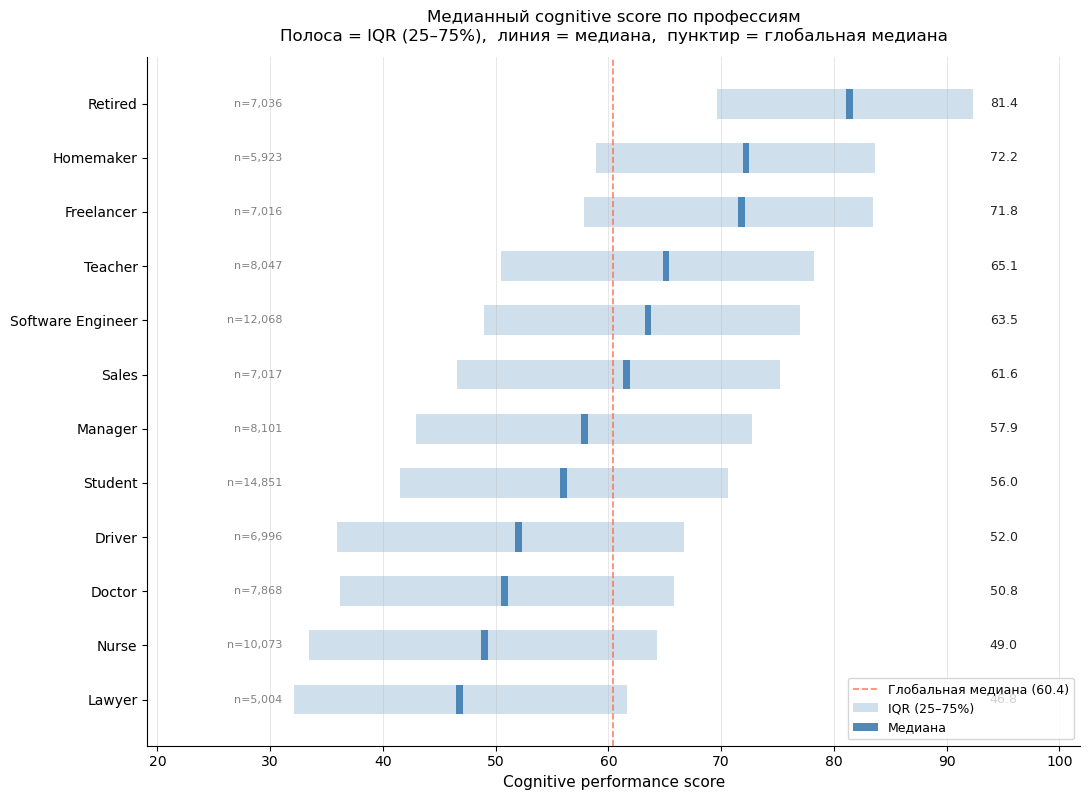

,occupation,median,Q25,Q75,IQR,count
7,Retired,81.4,69.6,92.32,22.73,7036
3,Homemaker,72.2,58.9,83.60,24.70,5923
2,Freelancer,71.8,57.8,83.50,25.70,7016
11,Teacher,65.1,50.5,78.20,27.70,8047
9,Software Engineer,63.5,49.0,77.00,28.00,12068
8,Sales,61.6,46.6,75.20,28.60,7017
5,Manager,57.9,42.9,72.70,29.80,8101
10,Student,56.0,41.5,70.60,29.10,14851
1,Driver,52.0,35.9,66.70,30.80,6996
0,Doctor,50.8,36.2,65.80,29.60,7868


In [26]:
def plot_cognitive_by_occupation(df, col='cognitive_performance_score',
                                  group_col='occupation'):
    stats = (df.groupby(group_col)[col]
               .agg(median='median',
                    q25=lambda x: x.quantile(0.25),
                    q75=lambda x: x.quantile(0.75),
                    count='count')
               .reset_index()
               .sort_values('median', ascending=True))

    fig, ax = plt.subplots(figsize=(11, len(stats) * 0.55 + 1.5))
    y_pos = np.arange(len(stats))

    # IQR полоса
    ax.barh(y_pos,
            stats['q75'] - stats['q25'],
            left=stats['q25'],
            height=0.55,
            color='steelblue', alpha=0.25,
            label='IQR (25–75%)')

    # Линия медианы внутри полосы
    ax.barh(y_pos,
            width=0.6,
            left=stats['median'] - 0.3,
            height=0.55,
            color='steelblue', alpha=0.95,
            label='Медиана')

    # Подписи медианы и n
    x_label_right = stats['q75'].max() + 1.5
    x_label_left  = stats['q25'].min() - 1.0

    for i, row in enumerate(stats.itertuples()):
        ax.text(x_label_right, i, f'{row.median:.1f}',
                va='center', ha='left', fontsize=9, color='#222222')
        ax.text(x_label_left, i, f'n={row.count:,}',
                va='center', ha='right', fontsize=8, color='gray')

    # Глобальная медиана
    global_median = df[col].median()
    ax.axvline(global_median, color='tomato', linewidth=1.2,
               linestyle='--', alpha=0.8,
               label=f'Глобальная медиана ({global_median:.1f})')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(stats[group_col], fontsize=10)
    ax.set_xlabel('Cognitive performance score', fontsize=11)
    ax.set_title(
        'Медианный cognitive score по профессиям\n'
        'Полоса = IQR (25–75%),  линия = медиана,  пунктир = глобальная медиана',
        fontsize=12, pad=12)

    ax.set_xlim(x_label_left - 12, x_label_right + 8)
    ax.legend(loc='lower right', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='x', alpha=0.3, linewidth=0.7)

    plt.tight_layout()
    plt.show()

    # Сводная таблица
    out = stats.copy()
    out['IQR'] = (out['q75'] - out['q25']).round(2)
    out = out.rename(columns={'q25': 'Q25', 'q75': 'Q75'})
    return (out[['occupation', 'median', 'Q25', 'Q75', 'IQR', 'count']]
          .sort_values('median', ascending=False)
          .round(2))

plot_cognitive_by_occupation(df)

Интересное(правда довольно очевидное наблюдение) что у тех, кто владеет свободным графиком работы, лучше когнитивный скор. Теперь интересно взглянуть на то, медианный уровень стресса и количество рабочих часов у каждой из выбранных групп.

In [28]:
# Проверяем через stress_score и work_hours_that_day
autonomy_check = (df.groupby('occupation')
                    [['stress_score', 'work_hours_that_day', 
                      'sleep_duration_hrs', 'cognitive_performance_score']]
                    .median()
                    .sort_values('cognitive_performance_score', ascending=False))
autonomy_check.round(2)

,stress_score,work_hours_that_day,sleep_duration_hrs,cognitive_performance_score
occupation,,,,
Retired,2.5,0.7,7.97,81.4
Homemaker,4.8,4.3,7.18,72.2
Freelancer,5.0,6.2,7.29,71.8
Teacher,5.8,6.7,6.82,65.1
Software Engineer,5.3,8.3,6.40,63.5
Sales,5.6,8.2,6.27,61.6
Manager,5.9,8.7,6.10,57.9
Student,5.9,4.3,5.96,56.0
Driver,6.3,8.3,5.74,52.0


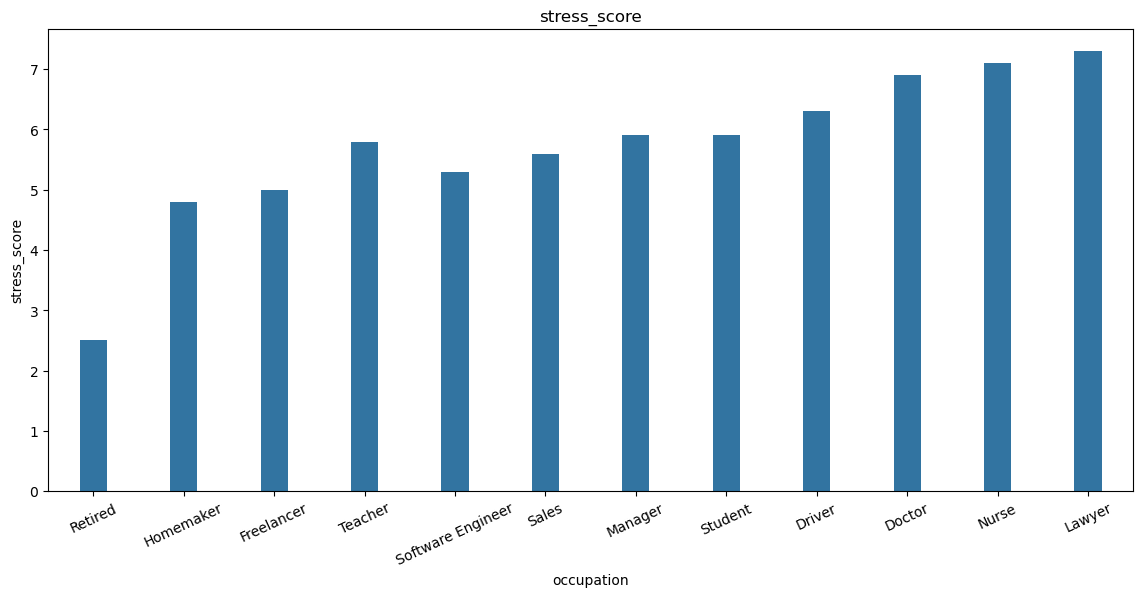

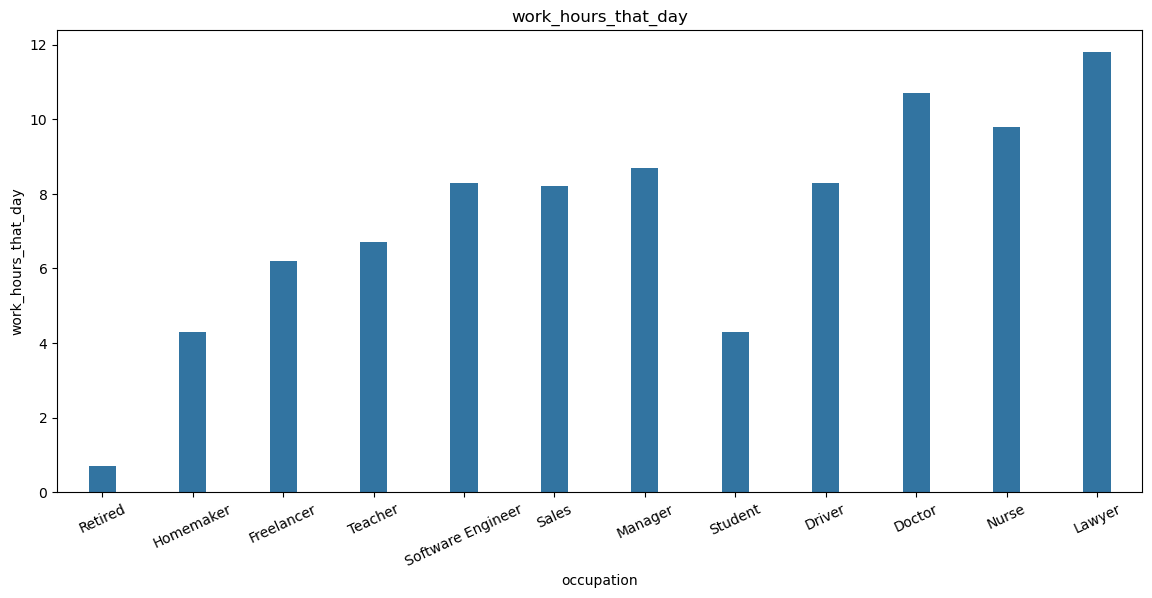

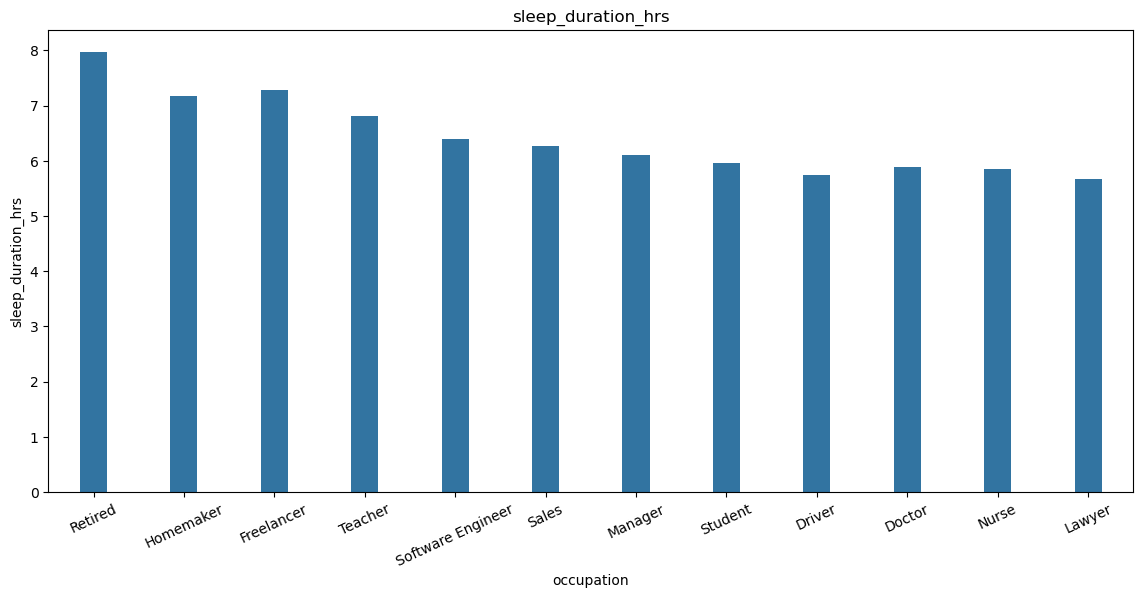

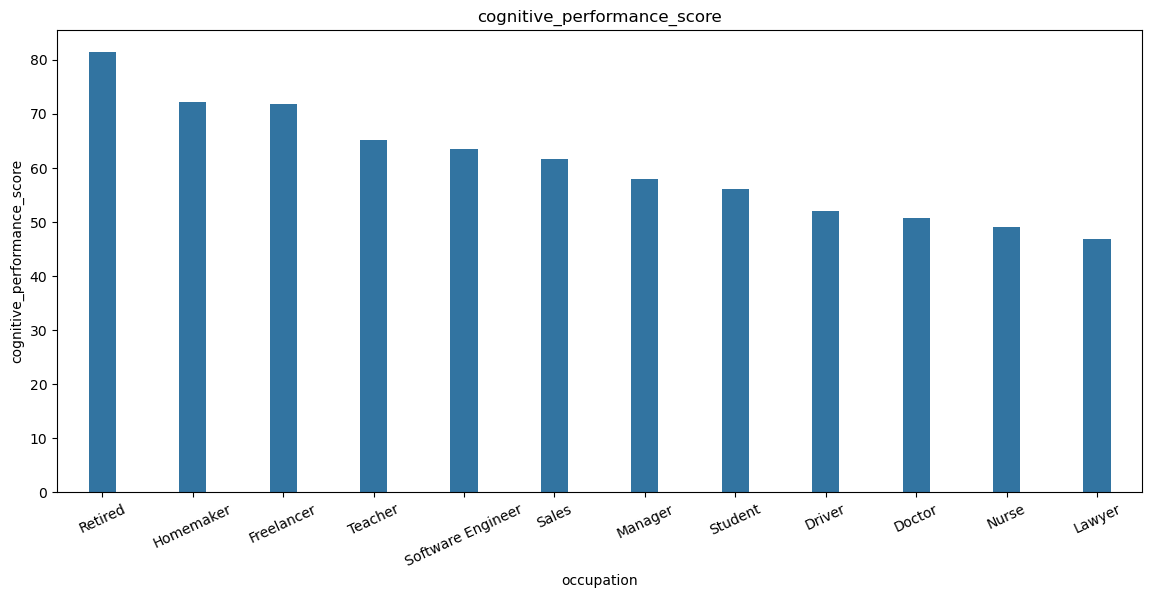

In [49]:


for i in range(len(autonomy_check.columns.tolist())):
    fig, axes = plt.subplots(1, 1, figsize=(14, 6))
    sns.barplot(
        data=autonomy_check, 
        x="occupation", 
        y=autonomy_check.columns.tolist()[i], 
        ax=axes, width=0.3,
        
    )
    axes.set_title(autonomy_check.columns.tolist()[i])
    plt.xticks(rotation=25)

# sns.barplot(
#     data=autonomy_check, 
#     x="occupation", 
#     y="work", 
#     ax=axes[0], width=0.5)


Видна очевидная зависимость!!!! Опять топ три с конца по когнитивному скору топ 3 по уровню стресса в работе

Lawyer и Doctor — профессии с наибольшим уровнем образования, но они в самом низу. Это контринтуитивно и указывает что когнитивный скор в датасете измеряет не интеллект или образованность, а текущее функциональное состояние мозга — которое убивается недосыпом и стрессом

In [50]:
# Ключевой вопрос: какой ценой достигается карьера?
career_cost = (df[df['occupation'].isin(['Lawyer', 'Doctor', 'Retired', 'Freelancer'])]
                 .groupby('occupation')
                 [['sleep_duration_hrs', 'sleep_quality_score',
                   'stress_score', 'work_hours_that_day',
                   'rem_percentage', 'deep_sleep_percentage']]
                 .median())
career_cost.round(2)

,sleep_duration_hrs,sleep_quality_score,stress_score,work_hours_that_day,rem_percentage,deep_sleep_percentage
occupation,,,,,,
Doctor,5.89,4.2,6.9,10.7,19.9,19.8
Freelancer,7.29,5.8,5.0,6.2,20.6,20.6
Lawyer,5.67,3.9,7.3,11.8,19.7,19.8
Retired,7.97,6.7,2.5,0.7,20.7,20.6


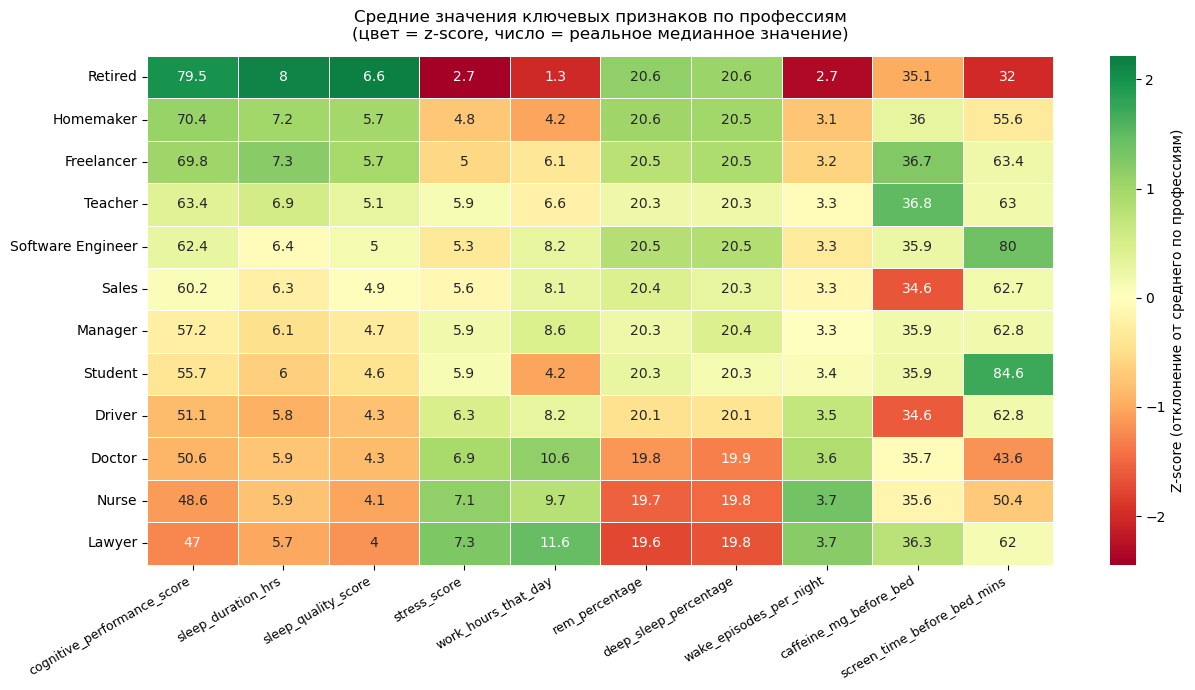

In [58]:
features_of_interest = [
    'cognitive_performance_score',
    'sleep_duration_hrs',
    'sleep_quality_score', 
    'stress_score',
    'work_hours_that_day',
    'rem_percentage',
    'deep_sleep_percentage',
    'wake_episodes_per_night',
    'caffeine_mg_before_bed',
    'screen_time_before_bed_mins'
]

# Медианы по профессиям, нормированные для сравнимости
heatmap_data = (df.groupby('occupation')[features_of_interest]
                  .mean()
                  .sort_values('cognitive_performance_score', ascending=False))

# Нормируем наши данные
heatmap_norm = (heatmap_data - heatmap_data.mean()) / heatmap_data.std()

plt.figure(figsize=(13, 7))
sns.heatmap(heatmap_norm, 
            annot=heatmap_data.round(1),  # реальные значения в ячейках
            fmt='g',
            cmap='RdYlGn',
            center=0,
            linewidths=0.5,
            cbar_kws={'label': 'Z-score (отклонение от среднего по профессиям)'})

plt.title('Средние значения ключевых признаков по профессиям\n'
          '(цвет = z-score, число = реальное медианное значение)',
          fontsize=12, pad=12)
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

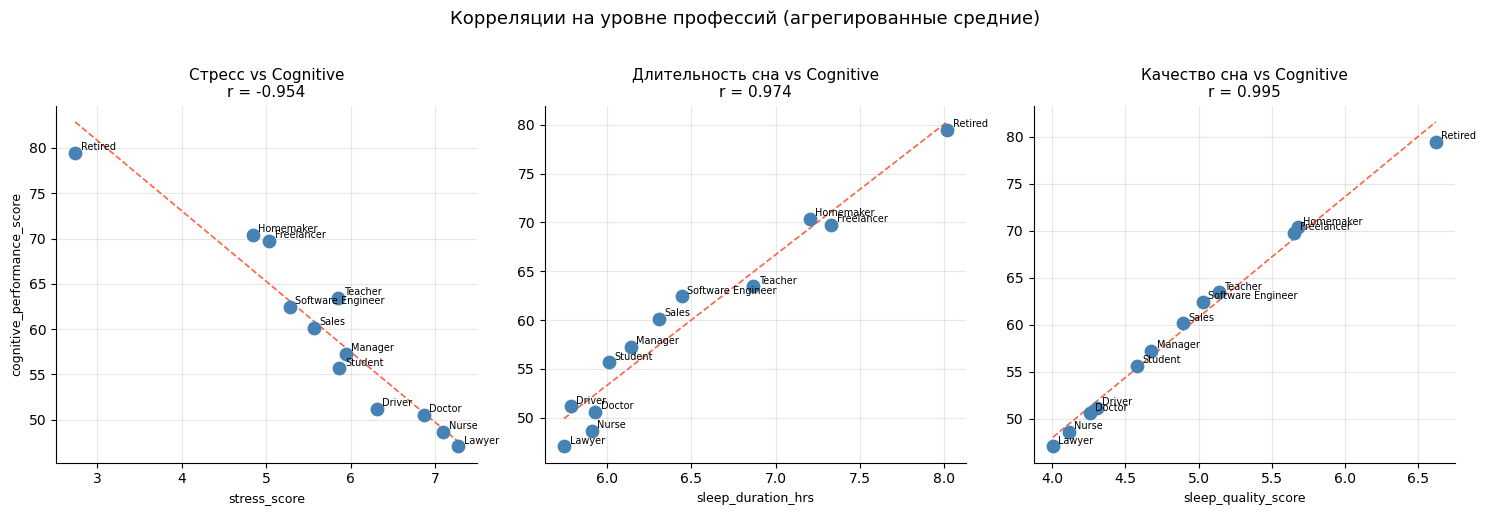

In [ ]:
# Агрегируем средние по профессиям !!!! ВАЖНО ЧТО ИМЕННО СРЕДНЕЕ !!!!
agg = (df.groupby('occupation')
         [['cognitive_performance_score', 'stress_score',
           'sleep_duration_hrs', 'sleep_quality_score', 'work_hours_that_day']]
         .mean()
         .reset_index())
# мы не переходили на индивидов

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

pairs = [
    ('stress_score',       'cognitive_performance_score', 'Стресс vs Cognitive'),
    ('sleep_duration_hrs', 'cognitive_performance_score', 'Длительность сна vs Cognitive'),
    ('sleep_quality_score','cognitive_performance_score', 'Качество сна vs Cognitive'),
]

for ax, (x_col, y_col, title) in zip(axes, pairs):
    ax.scatter(agg[x_col], agg[y_col], s=80, color='steelblue', zorder=3)
    
    # Подписи профессий
    for _, row in agg.iterrows():
        ax.annotate(row['occupation'],
                    (row[x_col], row[y_col]),
                    fontsize=7, ha='left',
                    xytext=(4, 2), textcoords='offset points')
    
    # Линия тренда
    z = np.polyfit(agg[x_col], agg[y_col], 1)
    p = np.poly1d(z)
    x_line = np.linspace(agg[x_col].min(), agg[x_col].max(), 100)
    ax.plot(x_line, p(x_line), 'tomato', linewidth=1.2, linestyle='--')
    
    # Корреляция
    r = agg[x_col].corr(agg[y_col])
    ax.set_title(f'{title}\nr = {r:.3f}', fontsize=11)
    ax.set_xlabel(x_col, fontsize=9)
    ax.set_ylabel(y_col if ax == axes[0] else '', fontsize=9)
    ax.grid(alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Корреляции на уровне профессий (агрегированные средние)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()